## Summarising Wage Distributions Data

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm, gaussian_kde
from matplotlib.lines import Line2D
import pyabc
from network_input_builder import *
path = "~/Documents/Documents - Nuff-Malham/GitHub/transition_abm/"


search function test passed!
✓ Plot saved as 'search_probability_vs_competition.png'

SAMPLE VALUES (Age=40, θ=5.0):
VacsPerApp = 0.000 → Search Probability = 0.0180 (1.80%)
VacsPerApp = 0.033 → Search Probability = 0.0211 (2.11%)
VacsPerApp = 0.100 → Search Probability = 0.0293 (2.93%)
VacsPerApp = 0.333 → Search Probability = 0.0883 (8.83%)
VacsPerApp = 0.500 → Search Probability = 0.1824 (18.24%)
VacsPerApp = 1.000 → Search Probability = 0.7311 (73.11%)


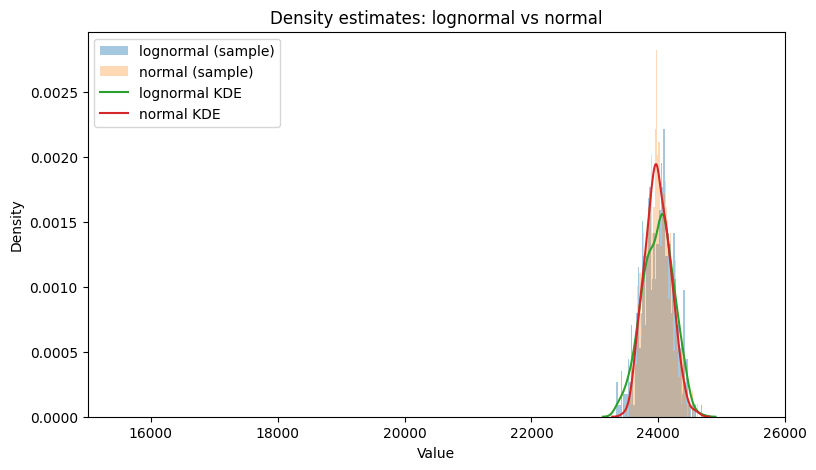

In [2]:
lognormals = 20000*np.random.lognormal(np.log(1.2), 0.01, 500)
normals = 20000*np.random.normal(1.2, 0.01, 500)

plt.figure(figsize=(9,5))
# histogram (density)
plt.hist(lognormals, bins=60, density=True, alpha=0.4, label='lognormal (sample)')
plt.hist(normals, bins=60, density=True, alpha=0.3, label='normal (sample)')

# KDEs (smooth)
sns.kdeplot(lognormals, bw_adjust=1, label='lognormal KDE')
sns.kdeplot(normals, bw_adjust=1, label='normal KDE')

plt.xlim(15000, 26000)   # optional zoom
plt.legend()
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Density estimates: lognormal vs normal")
plt.show()

In [5]:

mod_data, net_temp, vacs, occ_ids, occ_shocks_dat = network_input_builder("full_omn", complete = False, calib_date = ["2000-12-01", "2019-05-01"])

# wage_comp = mod_data['wages']
# wage_comp = pd.read_csv(path +"calibration_remote/dRC_Replication/data/ipums_variables_full_omn_w_exp.csv", delimiter = ",")
# wage_comp = wage_comp[['acs_occ_code', 'median_weekly_earnings']]
# wage_comp['median_annual_earnings'] = wage_comp['median_weekly_earnings'] * 52
ipums_input = pd.read_csv(path + "calibration_remote/dRC_Replication/data/ipums_variables_SOC_minor_w_exp.csv", delimiter = ",")
# wage_dist = pd.read_csv(path + "data/occ_macro_vars/OEWS/wage_distributions_full_omn.csv", compression='gzip',  delimiter=",", header = 0)
wage_comp = ipums_input[['SOC_minor', 'median_weekly_earnings']]
wage_comp['median_annual_earnings'] = wage_comp['median_weekly_earnings'] * 52
wage_dist = pd.read_csv("~/Documents/Documents - Nuff-Malham/GitHub/transition_abm/data/occ_macro_vars/OEWS/wage_distributions_omn_soc_minor.csv", delimiter=",", header = 0)
wage_full = wage_comp.merge(wage_dist, left_on='SOC_minor', right_on='SOC_minor', how='inner')

#occ_ids = pd.read_csv("/Users/ebbamark/OneDrive - Nexus365/GenerateOccMobNets/data/occ_names_employment_asec_occ.csv", delimiter=",")[['Code', 'Label']]
occ_ids = pd.read_csv("/Users/ebbamark/OneDrive - Nexus365/GenerateOccMobNets/data/soc_2010_minor_codes_employment_asec.csv", delimiter=",")[['SOC']]
occ_ids['Label'] = occ_ids['SOC']
occ_ids['acs_occ_code'] = occ_ids['SOC']
occ_ids = occ_ids.rename(columns={"Label": "label", "SOC": "Code"})
occ_ids['id'] = occ_ids.index.values

wage_full = wage_full.merge(occ_ids, left_on = "SOC_minor", right_on = "Code")

def fit_lognormal_all(p10, p25, p50, p75, p90):
    """Fit lognormal parameters (mu, sigma) to multiple percentiles."""
    quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
    observed = np.log(np.array([p10, p25, p50, p75, p90]))  # log wages
    def loss(params):
        mu, sigma = params
        predicted = mu + sigma * norm.ppf(quantiles)
        return np.sum((predicted - observed) ** 2)

    # Initial guess
    init = [np.log(p50), 0.3]
    result = minimize(loss, init, bounds=[(None, None), (1e-6, None)])

    return result.x  # (mu, sigma)

print(wage_full)
def draw_samples_safe(row, n_draws):
    print(row)
    # calculate mu/sigma from percentiles
    mu_calc, sigma_calc = fit_lognormal_all(
        row['a_pct10'], row['a_pct25'], row['a_median'], row['a_pct75'], row['a_pct90']
    )

    # check once per session/cell run (do not save diagnostics to the output dataframe)

    assert(np.isclose(mu_calc, row['mu'], rtol=1e-3, atol=1e-6))
    assert(np.isclose(sigma_calc, row['sigma'], rtol=1e-3, atol=1e-6))

    # if not (mu_close and sigma_close):
    #     print(
    #         f"Occ {row['acs_occ_code']}: mu_calc={float(mu_calc):.6f} mu_row={float(row['mu']):.6f} "
    #         f"sigma_calc={float(sigma_calc):.6f} sigma_row={float(row['sigma']):.6f}"
    #     )
    # else:
    #     print(
    #         "passed"
    #         # f"Occ {row['acs_occ_code']}: mu and sigma close "
    #         # f"(mu_diff={float(mu_calc - row['mu']):.3e}, sigma_diff={float(sigma_calc - row['sigma']):.3e})"
    #     )

    # use the stored mu/sigma for sampling (keeps behavior)
    lognorm_draws = np.random.lognormal(row['mu'], row['sigma'], n_draws)

    median = float(row['a_median'])
    sd = 0.05 * median
    normal_draws = np.random.normal(median, sd, n_draws)
    normal_draws = np.clip(normal_draws, 0, None)

    old_median = float(row['median_annual_earnings'])
    old_sd = 0.05 * old_median
    old_draws = np.random.normal(old_median, old_sd, n_draws)
    old_draws = np.clip(old_draws, 0, None)

    return pd.DataFrame({
        'occupation': row.get('acs_occ_code','unknown'),
        'occupation_name': (
            occ_ids.loc[occ_ids['Code'] == row.get('acs_occ_code', -1), 'label'].values[0]
            if not occ_ids.loc[occ_ids['Code'] == row.get('acs_occ_code', -1)].empty else 'unknown'
        ),
        'lognormal_draw': lognorm_draws,
        'normal_median_draw': normal_draws,
        'old_median_draw': old_draws
    })

samples = pd.concat(
    wage_full.apply(draw_samples_safe, axis=1, args=(1000,)).values,
    ignore_index=True
)
print(samples['occupation'].unique())



Using Full Corrected OMN
(528, 528)
Build mod_data.
Nodes (n): 528
Initialised network.
   SOC_minor  median_weekly_earnings_x  median_annual_earnings  X.1  year  \
0    11-1000                    1615.0                 83980.0    1  2012   
1    11-2000                    1442.0                 74984.0    2  2012   
2    11-3000                    1250.0                 65000.0    3  2012   
3    11-9000                     996.0                 51792.0    4  2012   
4    13-1000                     892.0                 46384.0    5  2012   
..       ...                       ...                     ...  ...   ...   
89   53-3000                     600.0                 31200.0   90  2012   
90   53-4000                     746.0                 38792.0   91  2012   
91   53-5000                     634.0                 32968.0   92  2012   
92   53-6000                     450.0                 23400.0   93  2012   
93   53-7000                     456.0                 23712.0   

/var/folders/8b/bf75_lhn2ks3ff8jvrhctcvc0000gr/T/ipykernel_9022/171901272.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wage_comp['median_annual_earnings'] = wage_comp['median_weekly_earnings'] * 52


In [6]:
save = False
if save:
    base_path = os.path.expanduser("~/Documents/Documents - Nuff-Malham/GitHub/transition_abm/")
    save_dir = os.path.join(base_path, "calibration_remote/output/plots_wage_distributions/")

# Loop over each occupation in your samples DataFrame
for occ_name in samples['occupation'].unique():
    subset = samples[samples['occupation'] == occ_name]

    # Get a readable name if available
    occ_label = subset['occupation_name'].iloc[0] if 'occupation_name' in subset.columns else ''
    safe_label = str(occ_label).replace('/', '_').replace(' ', '_')
    safe_occ = str(occ_name).replace('/', '_')

    plt.figure(figsize=(10,6))

    plt.hist(subset['normal_median_draw'], bins=40, alpha=0.5, density=True,
             label='Normal w. New Data (Median ±5%)')
    plt.hist(subset['old_median_draw'], bins=40, alpha=0.5, density=True,
             label='Normal w. Old Data (Median ±5%)')
    plt.hist(subset['lognormal_draw'], bins=40, alpha=0.5, density=True,
             label='Fitted Lognormal (New Data)')

    plt.suptitle("Wage Draw Comparison", fontsize=14)
    plt.title(f"Occupation: {occ_name} - {occ_label}", fontsize=10)
    plt.xlabel("Wage ($)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()

    # Save the figure
    if save:
        file_name = f"{safe_occ}_{safe_label}.png"
        plt.savefig(f'{save_dir}detailed_occs/{file_name}', dpi=300)
        plt.close()  # close to free memory
    else:
        #plt.show()
        plt.close()

if save:
    print(f"Saved one plot per occupation to: {save_dir}")


['11-1000' '11-2000' '11-3000' '11-9000' '13-1000' '13-2000' '15-1100'
 '15-2000' '17-1000' '17-2000' '17-3000' '19-1000' '19-2000' '19-3000'
 '19-4000' '21-1000' '21-2000' '23-1000' '23-2000' '25-1000' '25-2000'
 '25-3000' '25-4000' '25-9000' '27-1000' '27-2000' '27-3000' '27-4000'
 '29-1000' '29-2000' '29-9000' '31-1000' '31-2000' '31-9000' '33-1000'
 '33-2000' '33-3000' '33-9000' '35-1000' '35-2000' '35-3000' '35-9000'
 '37-1000' '37-2000' '37-3000' '39-1000' '39-2000' '39-3000' '39-4000'
 '39-5000' '39-6000' '39-7000' '39-9000' '41-1000' '41-2000' '41-3000'
 '41-4000' '41-9000' '43-1000' '43-2000' '43-3000' '43-4000' '43-5000'
 '43-6000' '43-9000' '45-1000' '45-2000' '45-3000' '45-4000' '47-1000'
 '47-2000' '47-3000' '47-4000' '47-5000' '49-1000' '49-2000' '49-3000'
 '49-9000' '51-1000' '51-2000' '51-3000' '51-4000' '51-5100' '51-6000'
 '51-7000' '51-8000' '51-9000' '53-1000' '53-2000' '53-3000' '53-4000'
 '53-5000' '53-6000' '53-7000']


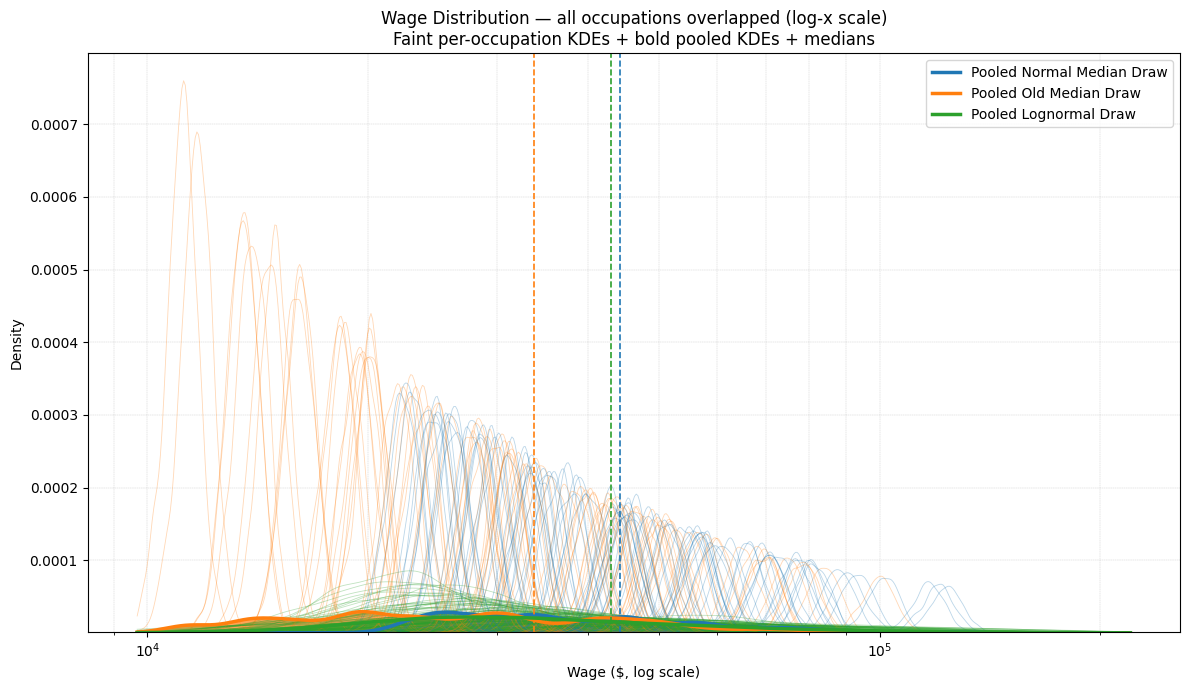

In [7]:
from scipy.stats import gaussian_kde
# choose colors for the three draw types

# color scheme
colors = {
    'normal_median_draw': '#1f77b4',     # blue
    'old_median_draw': '#ff7f0e',   # orange
    'lognormal_draw': '#2ca02c'   # green
}

def clean_array(a, occ_name=None, col_name=None):
    """Clean an array and print warnings if NAs or infs are found."""
    a = np.asarray(a, dtype=float)
    n_before = len(a)
    n_nonna = np.isfinite(a).sum()
    n_removed = n_before - n_nonna
    if n_removed > 0 and occ_name is not None and col_name is not None:
        print(f"NaNs/Infs detected for occupation {occ_name} ({col_name}): "
              f"{n_removed} of {n_before} values removed.")
    a = a[np.isfinite(a)]
    a = a[a > 0]  # remove zeros and negatives (for log scale)
    return a

# optionally limit number of occupations
occ_list = samples['occupation'].unique()
print(occ_list)
# occ_list = np.random.choice(occ_list, size=min(100, len(occ_list)), replace=False)

# pooled range
all_vals = np.concatenate([
    clean_array(samples['normal_median_draw']),
    clean_array(samples['old_median_draw']),
    clean_array(samples['lognormal_draw'])
])

xmin, xmax = np.percentile(all_vals, [0.5, 99.5])
xmin = max(xmin, 1e-6)
xs = np.exp(np.linspace(np.log(xmin/1.2), np.log(xmax*1.2), 600))

plt.figure(figsize=(12, 7))

alpha_per_occ = 0.3

# --- Per-occupation faint KDEs ---
for occ in occ_list:
    subset = samples[samples['occupation'] == occ]
    if len(subset) < 5:
        continue
    for col in ['normal_median_draw', 'old_median_draw', 'lognormal_draw']:
        vals = clean_array(subset[col].values, occ_name=occ, col_name=col)
        vals = vals[(vals >= xs.min()) & (vals <= xs.max())]
        if vals.size < 3:
            continue
        try:
            kde = gaussian_kde(np.log(vals))
            density = kde(np.log(xs)) / xs
            plt.plot(xs, density, color=colors[col], alpha=alpha_per_occ, linewidth=0.6)
        except Exception as e:
            print(f" KDE failed for occupation {occ} ({col}): {e}")
            continue

# --- Pooled KDEs (bold + filled) ---
for col in ['normal_median_draw', 'old_median_draw', 'lognormal_draw']:
    vals = clean_array(samples[col].values)
    vals = vals[(vals >= xs.min()) & (vals <= xs.max())]
    if vals.size < 3:
        continue
    kde = gaussian_kde(np.log(vals))
    density = kde(np.log(xs)) / xs
    plt.fill_between(xs, density, color=colors[col], alpha=0.7)
    plt.plot(xs, density, color=colors[col], linewidth=2.5, label=f'Pooled {col.replace("_", " ").title()}')
    # Median line
    med = np.median(vals)
    plt.axvline(med, color=colors[col], linestyle='--', linewidth=1.2)

plt.xscale('log')
plt.ylim(bottom=1e-6)
plt.xlabel('Wage ($, log scale)')
plt.ylabel('Density')
plt.title('Wage Distribution — all occupations overlapped (log-x scale)\n'
          'Faint per-occupation KDEs + bold pooled KDEs + medians')
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.3, alpha=0.7)
plt.tight_layout()

#out_file = os.path.join(save_dir, 'all_occupations_overlaid_wage_distributions_logx_with_warnings.png')
#plt.savefig(out_file, dpi=300)
plt.show()

# print(f"Saved improved plot to: {out_file}")


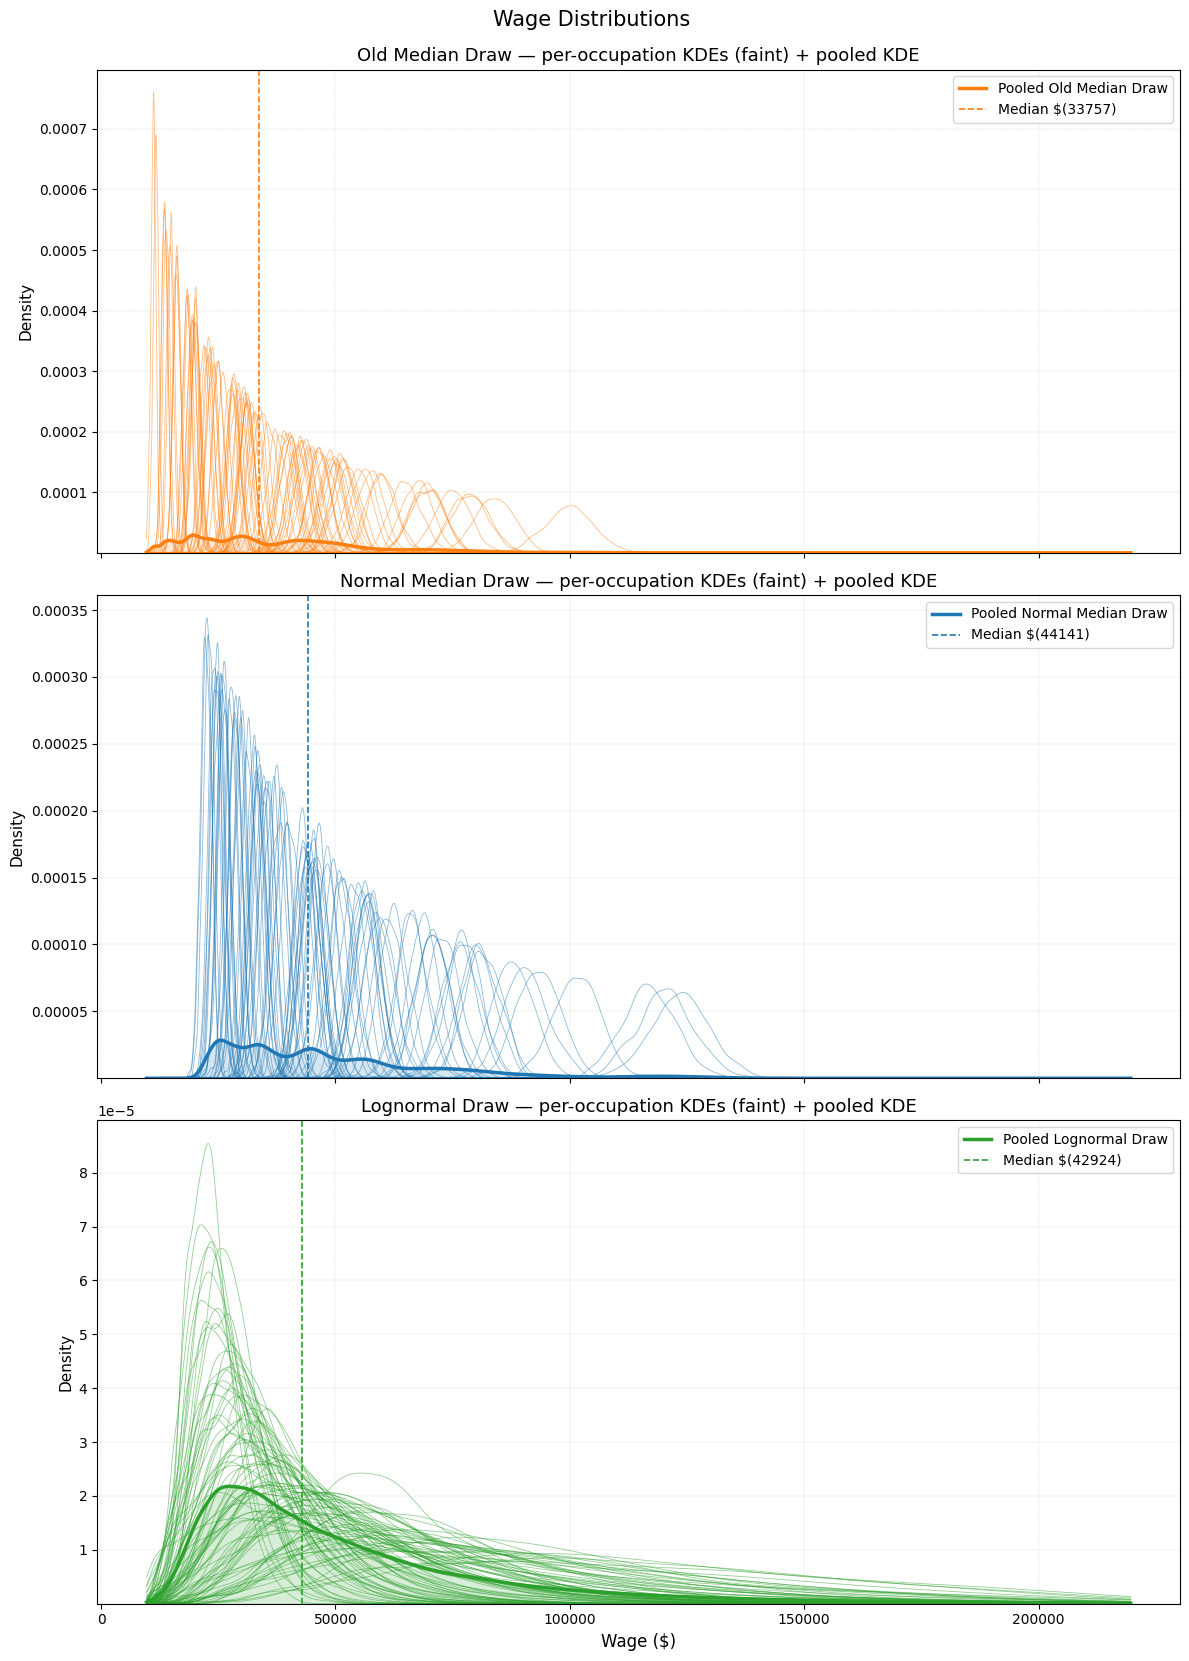

In [15]:
# color scheme (one color used per plot, mapped for labels/file names)
colors = {
    'normal_median_draw': '#1f77b4',     # blue
    'old_median_draw': '#ff7f0e',   # orange
    'lognormal_draw': '#2ca02c'   # green
}

def clean_array(a, occ_name=None, col_name=None):
    """Clean an array and print warnings if NAs or infs are found."""
    a = np.asarray(a, dtype=float)
    n_before = len(a)
    n_nonna = np.isfinite(a).sum()
    n_removed = n_before - n_nonna
    if n_removed > 0 and occ_name is not None and col_name is not None:
        print(f"NaNs/Infs detected for occupation {occ_name} ({col_name}): "
              f"{n_removed} of {n_before} values removed.")
    a = a[np.isfinite(a)]
    a = a[a > 0]  # remove zeros and negatives (for log scale)
    return a

# optionally subsample to reduce overplotting
occ_list_all = samples['occupation'].unique()
# occ_list = np.random.choice(occ_list_all, size=min(150, len(occ_list_all)), replace=False)
occ_list = occ_list_all

# pooled plotting range (shared across all subplots)
all_vals = np.concatenate([
    clean_array(samples['normal_median_draw']),
    clean_array(samples['old_median_draw']),
    clean_array(samples['lognormal_draw'])
])
if all_vals.size == 0:
    raise RuntimeError("No positive finite draws found in samples.")

xmin, xmax = np.percentile(all_vals, [0.5, 99.5])
xmin = max(xmin, 1e-6)
xs = np.exp(np.linspace(np.log(xmin / 1.2), np.log(xmax * 1.2), 600))

# plotting parameters
alpha_per_occ = 0.5
pooled_fill_alpha = 0.18
pooled_linewidth = 2.5
per_occ_linewidth = 0.6
min_vals_for_kde = 3

# --- Create 3 vertically stacked subplots ---
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
draw_types = ['old_median_draw', 'normal_median_draw', 'lognormal_draw']

for ax, col in zip(axes, draw_types):
    color = colors[col]

    # per-occupation faint KDEs
    for occ in occ_list:
        subset = samples[samples['occupation'] == occ]
        if len(subset) < 5:
            continue
        vals = clean_array(subset[col].values, occ_name=occ, col_name=col)
        vals = vals[(vals >= xs.min()) & (vals <= xs.max())]
        if vals.size < min_vals_for_kde or np.nanstd(vals) == 0:
            continue
        try:
            kde = gaussian_kde(np.log(vals))
            density = kde(np.log(xs)) / xs
            ax.plot(xs, density, color=color, alpha=alpha_per_occ, linewidth=per_occ_linewidth)
        except Exception as e:
            print(f"⚠️ KDE failed for occupation {occ} ({col}): {e}")
            continue

    # pooled KDE (bold + filled)
    pooled_vals = clean_array(samples[col].values)
    pooled_vals = pooled_vals[(pooled_vals >= xs.min()) & (pooled_vals <= xs.max())]
    if pooled_vals.size >= min_vals_for_kde and np.nanstd(pooled_vals) > 0:
        try:
            kde = gaussian_kde(np.log(pooled_vals))
            density = kde(np.log(xs)) / xs
            ax.fill_between(xs, density, color=color, alpha=pooled_fill_alpha)
            ax.plot(xs, density, color=color, linewidth=pooled_linewidth,
                    label=f'Pooled {col.replace("_", " ").title()}')
            med = np.median(pooled_vals)
            ax.axvline(med, color=color, linestyle='--', linewidth=1.2, label=f'Median $({int(med)})')
        except Exception as e:
            print(f"⚠️ Pooled KDE failed for {col}: {e}")
    else:
        if pooled_vals.size > 0:
            med = np.median(pooled_vals)
            ax.axvline(med, color=color, linestyle='--', linewidth=1.2, label=f'Median (${int(med)})')
            print(f"⚠️ Not enough pooled values for KDE for {col}. Showing median only.")

    # cosmetics
    #ax.set_xscale('log')
    ax.set_ylim(bottom=1e-8)
    ax.grid(True, which='both', ls='--', lw=0.3, alpha=0.6)
    pretty_col = col.replace('_', ' ').title()
    ax.set_title(f'{pretty_col} — per-occupation KDEs (faint) + pooled KDE', fontsize=13)
    ax.legend()

# shared labels and layout
axes[-1].set_xlabel('Wage ($)', fontsize=12)
for ax in axes:
    ax.set_ylabel('Density', fontsize=11)
fig.suptitle('Wage Distributions \n',
             fontsize=15, y=0.92)
fig.tight_layout(rect=[0, 0, 1, 0.94])

# save one PNG
#out_file = os.path.join(save_dir, 'all_occupations_wage_distributions_stacked_logx.png')
#plt.savefig(out_file, dpi=300)
plt.show()

#print(f"\n Saved combined 3-in-1 plot to: {out_file}")

In [ ]:
from PIL import Image
base_path = os.path.expanduser("~/Documents/Documents - Nuff-Malham/GitHub/transition_abm/")
save_dir = os.path.join(base_path, "calibration_remote/output/plots_wage_distributions/detailed_occs/")

# List your files (top-left, top-right, bottom-left, bottom-right)
file_names = [
    f"{save_dir}10_Chief_executives.png",
    f"{save_dir}360_Natural_sciences_managers.png",
    f"{save_dir}5510_Couriers_and_messengers.png",
    f"{save_dir}5400_Receptionists_and_information_clerks.png"
]

# Open all images
images = [Image.open(f) for f in file_names]

# --- Normalize image sizes ---
# Resize all to the same dimensions (use the smallest width/height to preserve quality)
widths, heights = zip(*(im.size for im in images))
target_width = min(widths)
target_height = min(heights)

images = [im.resize((target_width, target_height), Image.LANCZOS) for im in images]

# --- Create a blank canvas for 2x2 grid ---
cols, rows = 2, 2
grid_width = cols * target_width
grid_height = rows * target_height
combined = Image.new('RGB', (grid_width, grid_height), color=(255, 255, 255))

# --- Paste images in 2x2 layout ---
positions = [
    (0, 0),  # top-left
    (target_width, 0),  # top-right
    (0, target_height),  # bottom-left
    (target_width, target_height)  # bottom-right
]

for pos, im in zip(positions, images):
    combined.paste(im, pos)

# --- Save final combined image ---
output_file = os.path.join(save_dir, 'combined_sample_wage_distributions_2x2.png')
combined.save(output_file, dpi=(300, 300))
print(f"Saved combined 2×2 grid PNG: {output_file}")

In [ ]:
ipums_input = pd.read_csv(path + "calibration_remote/dRC_Replication/data/acs_onet_2010_ipums_vars_w_exp.csv", delimiter=",")

wage_comp = ipums_input[['acs_occ_code', 'median_weekly_earnings']]
wage_comp['median_annual_earnings'] = wage_comp['median_weekly_earnings'] * 52
wage_dist = pd.read_csv("~/Documents/Documents - Nuff-Malham/GitHub/transition_abm/data/occ_macro_vars/OEWS/wage_distributions_onet.csv", compression='gzip',  delimiter=",", header = 0)
wage_full = wage_comp.merge(wage_dist, left_on='acs_occ_code', right_on='acs_occ_code', how='inner')

# the z-scores corresponding to each quantile
qs = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
zs = norm.ppf(qs)   # array([-1.28155157, -0.67448975,  0.,  0.67448975,  1.28155157])

# Apply to whole DataFrame (vectorizing via .apply is fine for 528 rows)
mu_sigma = wage_full.apply(fit_mu_sigma_from_row, axis=1, result_type='expand')
mu_sigma.columns = ['mu', 'sigma']
wage_full = pd.concat([wage_full, mu_sigma], axis=1)


In [ ]:
def bup(beta_prev, alpha, h, r, omega, t):
    alpha = 1 - np.exp(-omega*t)
    beta = beta_prev + alpha*(h-r)

    return beta 

bup(1, 0.3, 0, 0.4, 0.1, 2)

t_unemp = np.arange(0, 50)



def simulate_zero_success(T=200, omega=0.08, r=0.05, beta0=1):
    # h_t = 0 at every time step
    h = 0
    betas = np.zeros(T+1)   # store beta_0 ... beta_T
    betas[0] = beta0

    for t in range(1, T+1):
        alpha_t = 1 - np.exp(-omega * t)
        beta_prev = betas[t-1]                   # previous value
        betas[t] = beta_prev + alpha_t * (h - r) # recursive update
        betas[t] = np.clip(betas[t], 0.0, 1.0)   # optional: keep in [0,1]

    return betas

T = 50
bet = simulate_zero_success(T)
print(bet[:10])   # first few values

plt.figure(figsize=(10, 6))
plt.plot(range(0, T+1), bet)

plt.xlabel('Months Unemployed')
plt.ylabel('Beliefs')
plt.title('Reservation Wage by Time Unemployed')
plt.grid(True)
plt.show()
